# Script to estimate airborne fraction trends with a two-stage

measurement-error approach

Bookkeeping series and classical ratio construction as robustness checks

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

This script analyses the LULC measurement series from the Global Carbon Budget 2025 dataset. It extracts the BLUE, OSCAR, and LUCE series as provided, and for each LULC model column from CLASSIC through VISIT-UT, it creates three derived series by adding each peat column (FAO_peat, LPX_Bern_peat, ORCHIDEE_peat). The script saves all extracted and derived series to CSV and generates plots for all combinations, including BLUE, OSCAR, and LUCE.

## Script to plot the dataset

Load the dataset.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
include(joinpath(@__DIR__, "estimation_functions.jl"))

dataframe_to_markdown_table (generic function with 1 method)

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
df = CSV.read(data_path, DataFrame)

lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")
lulc_df = CSV.read(lulc_path, DataFrame)
rename!(lulc_df, :year => :Year)

last(df[:, 1:5], 5)  # Show the last 5 rows to verify the data is loaded correctly

### Plotting the dataset

We plot the Fossil, LULC, and Growth series from the GCB 2025 dataset, which are the same used in the column land_use_change in the Global Carbon Budget 2025 dataset. Hence, we will keep them as they are provided without any modifications. For the LULC panel, we overlay all extracted and derived LULC measurements and also show their cross-series mean together with the GCB LULC column.


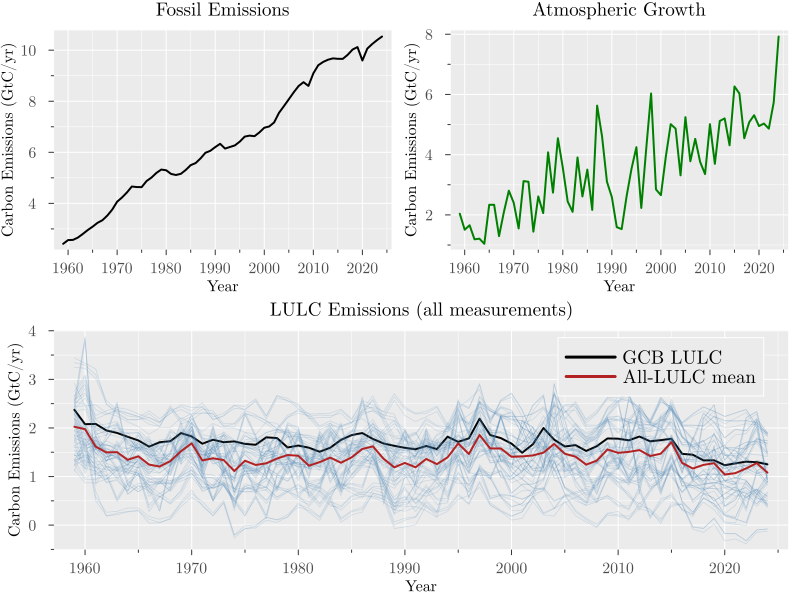

In [1]:
pf = plot(df.Year, df."fossil emissions excluding carbonation"; color = :black, linewidth = 2.0, title = "Fossil Emissions", xlabel = "Year", ylabel = "Carbon Emissions (GtC/yr)", legend = false)

pg = plot(df.Year, df."atmospheric growth"; color = :green, linewidth = 2.0, title = "Atmospheric Growth", xlabel = "Year", ylabel = "Carbon Emissions (GtC/yr)", legend = false)

pl = plot(df.Year, df."land-use change emissions"; color = :purple, linewidth = 2.0, title = "LULC Emissions", xlabel = "Year", ylabel = "Carbon Emissions (GtC/yr)", label = "GCB LULC")
plot!(pl, df.Year, df.BLUE; color = :steelblue, linewidth = 1.5, linestyle = :dot, label = "BLUE")
plot!(pl, df.Year, df.OSCAR; color = :darkorange, linewidth = 1.5, linestyle = :dashdot, label = "OSCAR")
plot!(pl, df.Year, df.LUCE; color = :gray, linewidth = 1.5, linestyle = :dash, label = "LUCE")

all_lulc_cols = filter(c -> c != "Year", names(lulc_df))
all_lulc_mean = vec(sum(Matrix(lulc_df[:, all_lulc_cols]), dims = 2) ./ length(all_lulc_cols))

pl_all = plot(
  df.Year,
  df."land-use change emissions";
  color = :black,
  linewidth = 2.0,
  title = "LULC Emissions (all measurements)",
  xlabel = "Year",
  ylabel = "Carbon Emissions (GtC/yr)",
  label = "GCB LULC",
)
for c in all_lulc_cols
  plot!(
    pl_all,
    lulc_df.Year,
    lulc_df[!, c];
    color = :steelblue,
    alpha = 0.18,
    linewidth = 0.8,
    label = "",
  )
end
plot!(pl_all, lulc_df.Year, all_lulc_mean; color = :firebrick, linewidth = 2.0, label = "All-LULC mean")


l = @layout [a b; c] 
pa = plot(pf, pg, pl; layout = l, size = (800, 600))

pall = plot(pf, pg, pl_all; layout = l, size = (800, 600))

In [1]:
savefig(pa, joinpath(@__DIR__, "..", "figures", "af_data.png"))
savefig(pa, joinpath(@__DIR__, "..", "figures", "af_data.pdf"))

savefig(pall, joinpath(@__DIR__, "..", "figures", "af_data_all_lulc.png"))
savefig(pall, joinpath(@__DIR__, "..", "figures", "af_data_all_lulc.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/af_data_all_lulc.pdf"